In [1]:
for _ in range(200)

SyntaxError: expected ':' (2599290436.py, line 1)

Selesai


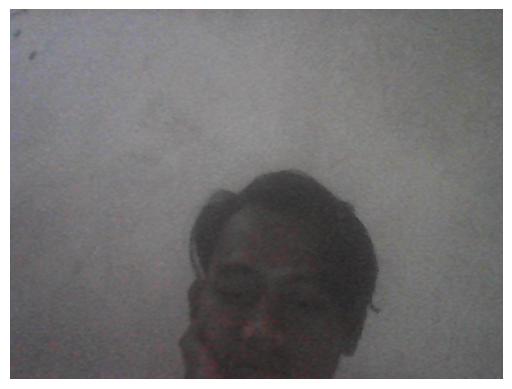

In [6]:
import cv2
import mediapipe as mp
import numpy as np
import time
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ================= INIT =================
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Kamera tidak bisa diakses")
    exit()

# ================= SETTINGS =================
history_len = 5
finger_history = [deque(maxlen=history_len) for _ in range(5)]

# ================= FUNCTIONS =================
def angle(a, b, c):
    ba = np.array([a.x - b.x, a.y - b.y])
    bc = np.array([c.x - b.x, c.y - b.y])
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))

def smooth_fingers(current):
    for i in range(5):
        finger_history[i].append(current[i])

    result = []
    for i in range(5):
        avg = sum(finger_history[i]) / len(finger_history[i])
        result.append(1 if avg >= 0.5 else 0)

    return result

def count_fingers(hand_landmarks):
    lm = hand_landmarks.landmark
    fingers = []

    # ibu jari sederhana
    fingers.append(1 if lm[4].x > lm[3].x else 0)

    tips = [8, 12, 16, 20]
    pips = [6, 10, 14, 18]
    mcps = [5, 9, 13, 17]

    for i in range(4):
        ang = angle(lm[mcps[i]], lm[pips[i]], lm[tips[i]])
        fingers.append(1 if ang > 160 else 0)

    return smooth_fingers(fingers), sum(fingers)

def detect_gesture(f):
    if f == [1,1,1,1,1]: return "BUKA"
    if f == [0,0,0,0,0]: return "TINJU"
    if f == [0,1,0,0,0]: return "SATU"
    if f == [0,1,1,0,0]: return "DUA"
    if f == [0,1,1,1,0]: return "TIGA"
    if f == [0,1,1,1,1]: return "EMPAT"
    return "UNKNOWN"

# ================= MAIN LOOP =================
print("Menjalankan kamera di Jupyter...")

for _ in range(200):  # batas frame supaya tidak freeze
    ret, frame = cap.read()
    if not ret:
        print("Gagal baca kamera")
        break

    frame = cv2.flip(frame, 1)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:

            mp_draw.draw_landmarks(
                frame,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )

            fingers, total = count_fingers(hand_landmarks)
            gesture = detect_gesture(fingers)

            cv2.putText(frame, f"Jari: {total}", (10, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

            cv2.putText(frame, gesture, (10, 80),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)

    # tampilkan di Jupyter
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    clear_output(wait=True)

cap.release()
hands.close()
print("Selesai")

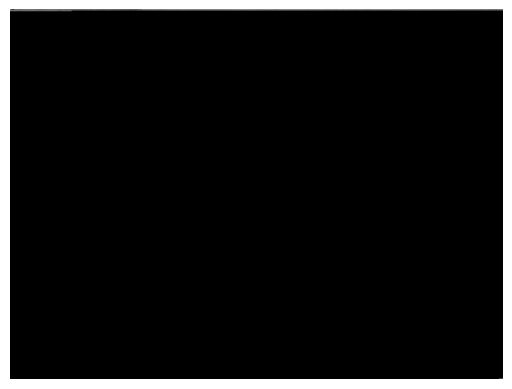

✅ Kamera berhasil tampil


In [5]:
%matplotlib inline

import cv2
import matplotlib.pyplot as plt

# coba buka kamera
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("❌ Kamera tidak bisa diakses")
else:
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print("❌ Gagal ambil gambar")
    else:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frame)
        plt.axis('off')
        plt.show()
        print("✅ Kamera berhasil tampil")

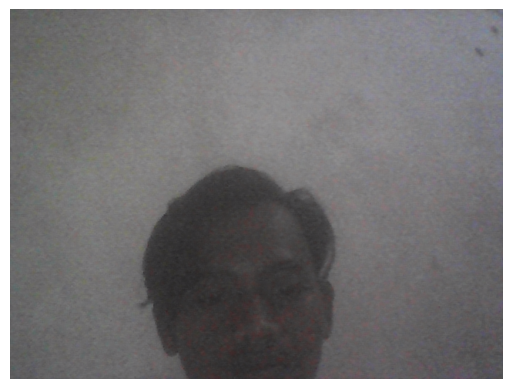

✅ Kamera berhasil tampil


In [7]:
%matplotlib inline

import cv2
import matplotlib.pyplot as plt
import time

cap = cv2.VideoCapture(0)

time.sleep(2)  # 🔥 tunggu kamera siap

for i in range(5):  # 🔥 buang frame awal
    cap.read()

ret, frame = cap.read()
cap.release()

if not ret:
    print("❌ Gagal ambil gambar")
else:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame)
    plt.axis('off')
    plt.show()
    print("✅ Kamera berhasil tampil")